# Train LightGB

### Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import datetime, timedelta
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from typing import cast
import numpy.typing as npt

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sys

root_path = Path.cwd().parent.parent
sys.path.append(str(root_path))

# personalized imports
from scripts.data_preparation.get_main import main_query_db
from scripts.data_preparation.preprocessed import main_preprocessed
from scripts.data_preparation.utils.progress_bar import TqdmCallback

d:\INSA_Lyon\2nd_semester\M1_Challenge_St_Exupery\.venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
d:\INSA_Lyon\2nd_semester\M1_Challenge_St_Exupery\.venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


### Global variables

In [2]:
root = Path(os.getcwd()).parent.parent
DATA_FOLDER_PATH = os.path.join(root, "data")
DATASET_PATH = os.path.join(DATA_FOLDER_PATH, "main_preprocessed.csv")
MODEL_FOLDER_PATH = os.path.join(root, "models")
MODEL_NbPaxTotal_FILENAME = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor.pkl")
MODEL_NbPaxPHMR_FILENAME = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor_PHMR.pkl")

TARGET = "NbPaxTotal"


# Today & tomorrow
now = datetime.now()
today = pd.Timestamp(now.date())
yesterday =  pd.Timestamp(today - timedelta(days=1))
two_days = pd.Timestamp(yesterday - timedelta(days=1))
tomorrow = pd.Timestamp(today + timedelta(days=1))

# LIMIT_DATE_TRAIN = two_days
# LIMIT_DATE_VALID = yesterday
# LIMIT_DATE_TEST = today


LIMIT_DATE_TRAIN = pd.Timestamp("2026-03-27")
LIMIT_DATE_VALID = pd.Timestamp("2026-03-28")
LIMIT_DATE_TEST = pd.Timestamp("2026-03-30")


PREDICTIONS_FILENAME = os.path.join(DATA_FOLDER_PATH, f"prediction_{LIMIT_DATE_VALID.strftime('%Y-%m-%d')}.csv")

### Load and prepare data

In [3]:
# Load the preprocessed data - or build the needed df.
if os.path.exists(DATASET_PATH) : 
    print('Loading preprocessed file ...')
    df = pd.read_csv(DATASET_PATH, encoding='utf-8')
else:
    ### Full pipeline
    # Query the data
    # Using BigQuery.
    print("Querying ...")
    main_query_db()
    print("Preprocessing ...")
    df = main_preprocessed()

Querying ...
Query execution: 
SELECT 
IdMovement,
IdADL,
IdAircraftType,
IdBusinessUnitType,
IdBusContactType,
IdTerminalType,
IdBagStatusDelivery,
NbFlight,
AirportCode,
airlineOACICode,
SysStopover,
AirportOrigin,
AirportPrevious,
ServiceCode,
flightNumber,
OperatorFlightNumber,
FlightNumberNormalized,
OperatorOACICodeNormalized,
LTScheduledDatetime,
LTScheduledTime,
LTExternalDatetime,
LTExternalDate,
LTExternalTime,
Direction,
Terminal,
SysTerminal,
FuelProvider,
ScheduleType,
NbOfSeats,
NbPaxTotal,
etl_origin, 
 FROM `va-sdh-adl-staging.aero_insa.mouvements_aero_insa`  
ORDER BY LTScheduledDatetime DESC


Downloading: 100%|██████████|
                    IdMovement                   IdADL IdAircraftType  \
0       20261025014500VOE02827  20261025014500VOE02827            320   
1       20261025004500EJU04486  20261025004500EJU04486            319   
2       20261025002500TVF08557  20261025002500TVF08557            73H   
3       20261025002500EJU04480  20261025002500EJU04480     

#### Data splitting

In [ ]:
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])


train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")
print(f"Test set: {len(test_df)} rows / From {test_df['LTScheduledDatetime'].min()} to {test_df['LTScheduledDatetime'].max()}")


Train set: 308873 rows / From 2023-01-01 00:05:00 to 2026-03-26 23:45:00
Valid set: 284 rows / From 2026-03-27 04:45:00 to 2026-03-27 23:55:00
Test set: 510 rows / From 2026-03-28 05:10:00 to 2026-03-29 23:50:00


#### Last preprocess

In [ ]:
#### Add PHMR part
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df['LTScheduledDatetime'] = train_df['LTScheduledDatetime'].astype(str)
valid_df['LTScheduledDatetime'] = valid_df['LTScheduledDatetime'].astype(str)
test_df['LTScheduledDatetime'] = test_df['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET])
y_valid = valid_df[TARGET]
X_test = test_df.drop(columns=[TARGET])

# Convert to categorical the needed features.
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')
    X_test[col] = X_test[col].astype('category')


print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_valid: {X_valid.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (308873, 686)
Shape X_valid: (284, 686)
Shape X_test: (510, 686)


In [ ]:
### Remove the less important features.
# this feature_importance.csv dataset is obtained by training the model once with all the features . Here to save time, we first remove the useless features to test the model performances with the new set of features.
# importance = pd.read_csv(os.path.join(DATA_PATH, 'feature_importance.csv'), encoding='utf-8')
# col_to_rmv_list = importance["feature"].tail(500).tolist()

# df = df.drop(columns=col_to_rmv_list)

### Train or Load the model

In [ ]:
# Check if there is an existing model.
if os.path.exists(MODEL_NbPaxTotal_FILENAME) :  # If yes, load the model 
    model = joblib.load(MODEL_NbPaxPHMR_FILENAME)
    print("Modèle chargé avec succès.")

    # 3. SÉCURITÉ CRITIQUE : Aligner l'ordre des colonnes
    # LightGBM a besoin des colonnes dans le même ordre que lors du .fit()
    if hasattr(model, 'feature_name_'):
        expected_features = model.feature_name_
        X_test = X_test[expected_features]


else : # Else, train it. 
    n_estimators = 10000

    model = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model.fit(
            X_train, y_train,         
            eval_set=[(X_valid, y_valid)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model, MODEL_NbPaxTotal_FILENAME)

In [ ]:
#### Original code.
# n_estimators = 10000

# model = lgb.LGBMRegressor(
#     objective="regression",      
#     n_estimators=n_estimators,      
#     learning_rate=0.01,
#     num_leaves=255,               
#     min_child_samples=5,
#     feature_fraction=0.8,
#     random_state=42,
#     verbose=-1
# )

# tqdm_callback = TqdmCallback(total=n_estimators)
# try:
#     model.fit(
#         X_train, y_train,         
#         eval_set=[(X_valid, y_valid)], 
#         eval_metric="mae",
#         callbacks=[
#             lgb.early_stopping(100),
#             tqdm_callback 
#         ]
#     )
# finally:
#     tqdm_callback.pbar.close()

# joblib.dump(model, MODEL_NbPaxTotal_FILENAME)

LightGBM training:   0%|          | 1/10000 [00:10<28:29:08, 10.26s/it, mae=58.9025]

Training until validation scores don't improve for 100 rounds


LightGBM training:  10%|▉         | 975/10000 [05:08<36:13,  4.15it/s, mae=12.2226]  

Early stopping, best iteration is:
[875]	valid_0's l1: 12.2311	valid_0's l2: 368.974


LightGBM training:  10%|▉         | 975/10000 [05:09<47:41,  3.15it/s, mae=12.2226]


### Prediction and Evaluation

#### Evaluation on the validation dataset

In [ ]:
predictions = model.predict(X_valid)
preds_array = cast(npt.NDArray[np.float32], predictions)
predictions = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── RÉSULTATS FINAUX ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── RÉSULTATS FINAUX ──
   MAE : 12.21 passengers
   R²  : 0.9188
   RMSE : 19.21


#### Predictions

In [ ]:
# predictions
predictions_nb_pax = model.predict(X_test)
preds_nb_pax_array = cast(npt.NDArray[np.float32], predictions_nb_pax)
predictions_nb_pax = np.maximum(0.0, preds_nb_pax_array)

# predictions_phmr_pax = model_phmr.predict(X_test_phmr)
# preds_phmr_pax = cast(npt.NDArray[np.float32], predictions_phmr_pax)
# predictions_phmr_pax = np.maximum(0.0, preds_phmr_pax)

df_final = X_test[['FlightNumberNormalized', 'LTScheduledDatetime']].copy() # + "PHMR column"
df_final.loc[:, 'NbPaxTotal'] = predictions_nb_pax
# df_final.loc[:, 'FarmsNbPaxPHMR'] = predictions_phmr_pax


df_final.to_csv(PREDICTIONS_FILENAME, encoding = 'utf-8', index=False)

#### Prediction evaluation

In [ ]:
### Implement Aristide's metrics



## Analysis

### NbPaxTotal

#### 1. Feature importance

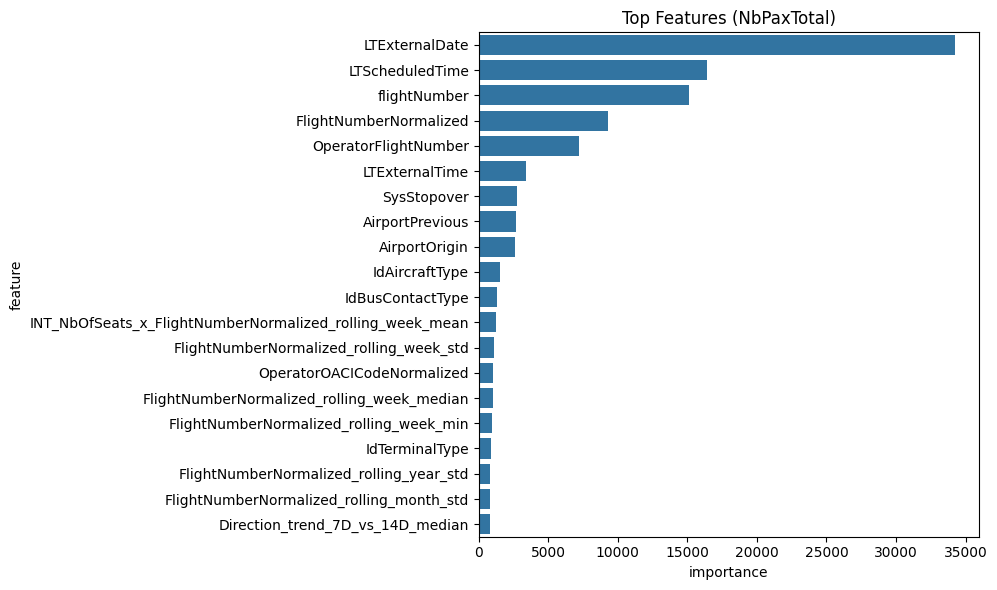

In [ ]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

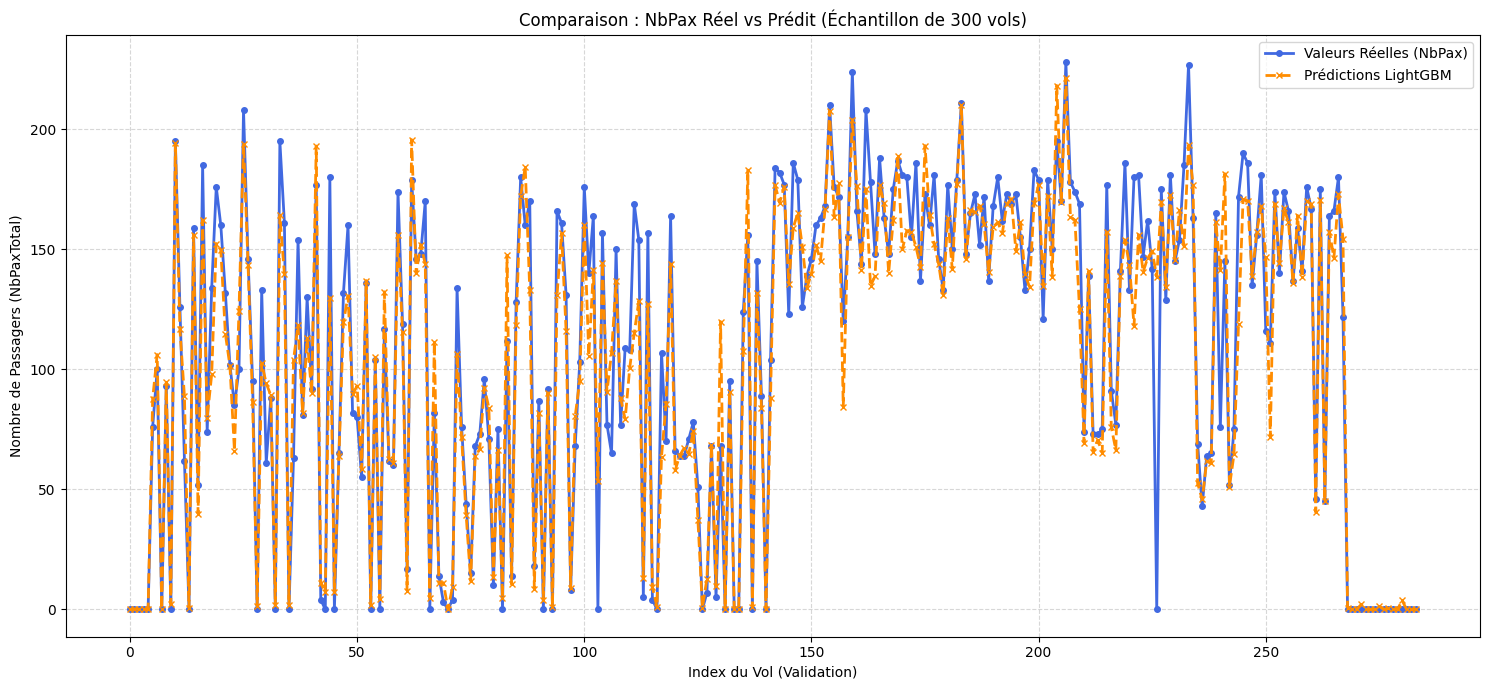

In [ ]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Valeurs Réelles (NbPax)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Prédictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparaison : NbPax Réel vs Prédit (Échantillon de {n_sample} vols)')
plt.ylabel('Nombre de Passagers (NbPaxTotal)')
plt.xlabel('Index du Vol (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [ ]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET, 
               "Predicted_NbPax", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_NbPax'] = display_df['Predicted_NbPax'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,NbPaxTotal,Predicted_NbPax,NbOfSeats,Abs_Error
330362,EJU04302,2026-03-27 18:45:00,0.000000,138.600000,156.000000,138.600000
330376,EZY02432,2026-03-27 21:30:00,76.000000,141.500000,186.000000,65.500000
330357,TVF07328,2026-03-27 17:55:00,180.000000,118.100000,189.000000,61.900000
163625,SEH00925,2026-03-27 19:30:00,169.000000,115.100000,180.000000,53.900000
163617,VLJ00051,2026-03-27 18:35:00,0.000000,53.400000,50.000000,53.400000
330380,TVF07313,2026-03-27 22:15:00,172.000000,119.000000,189.000000,53.000000
163644,BAW00363,2026-03-27 21:10:00,68.000000,119.900000,180.000000,51.900000
163558,AUA00353,2026-03-27 12:05:00,180.000000,129.900000,180.000000,50.100000
330345,TVF07309,2026-03-27 17:00:00,169.000000,125.100000,189.000000,43.900000
163631,EWG09412,2026-03-27 20:00:00,107.000000,63.700000,186.000000,43.300000


### FarmsNbPaxPHMR